This notebook is dedicated to analysing data.

Features include:
Using HSV (hue, saturation, value)
- hue(color type)
    range: [0, 179]
- saturation(color intensity)
    range: [0, 255] # 0-->more muted and grayish colors, 1-->vivid and strong colors
- value(brightness)
    range: [0, 255] # 0--> dark image, 1--> bright image
- contrast :std(img_gray)
    formula: features["contrast"] = float(img_gray.std())
- colorfulness : a formula which R, G, and B are used
    (Hasler & Süsstrunk style - 2003)
    formula: colorfulness = np.sqrt(std_rg**2 + std_yb**2) + 0.3 * np.sqrt(mean_rg**2 + mean_yb**2)

### Visual features and students' preference

count    156.000000
mean       2.467949
std        1.149585
min        1.000000
25%        2.000000
50%        2.000000
75%        3.000000
max        7.000000
Name: num_images_actual, dtype: float64


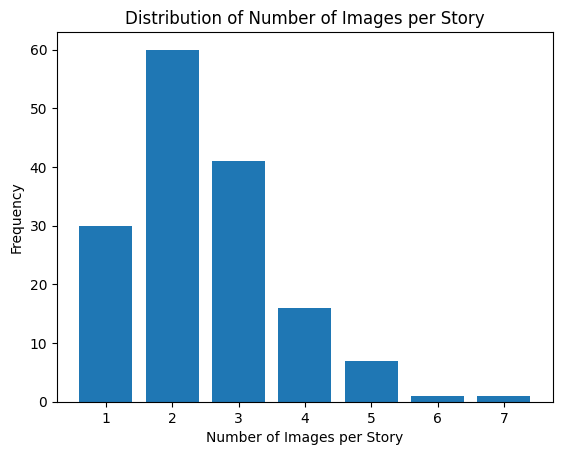

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

#-------------------------------
# Summary of data
# 'describe' feature gives min, max, mean, quartiles

story_features = pd.read_csv("../data/story_features_standardized_v2.csv")
describe_story_features = story_features["num_images_actual"].describe()
print(describe_story_features)

counts = story_features["num_images_actual"].value_counts().sort_index()

plt.bar(counts.index, counts.values)
plt.xlabel("Number of Images per Story")
plt.ylabel("Frequency")
plt.title("Distribution of Number of Images per Story")
plt.show()

# Correlation between Image Features

The "story_features_standardized_v2" is used rather than "merged_data_v2" because:
"merged_data_v2" data file compute relationship between features, weighted by number of students per story while
"story_features_standardized_v2" compute the relationship between features.

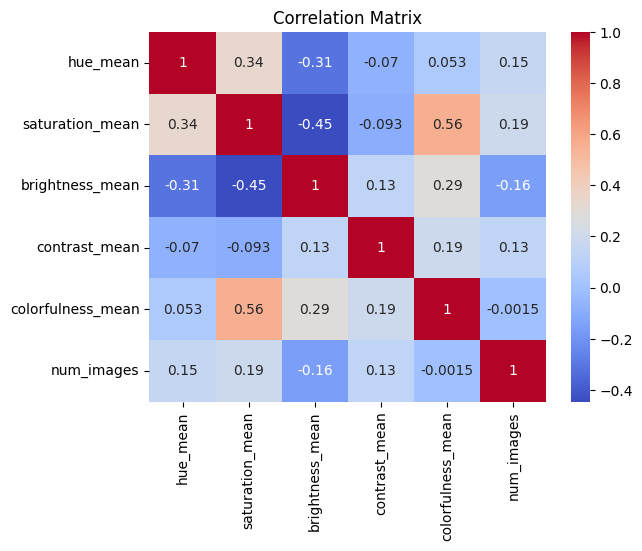

In [3]:
#----------------------------------
# Correlation between features
#----------------------------------
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

image_features = pd.read_csv("../data/story_features_standardized_v2.csv")

corr = image_features[
    ["hue_mean", "saturation_mean", "brightness_mean", "contrast_mean", "colorfulness_mean", "num_images"]
].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


# Image Features Effect on Student Preference
### Story level

In [ ]:
# Final
# Multiple regression
# ------------------------

import pandas as pd
import statsmodels.formula.api as smf

df = pd.read_csv("../data/story_features_and_pref_v2.csv")

def save_summary_table(model, filename):
    df_table = model.summary2().tables[1]
    df_table.to_excel(filename, index=True)

# Model 1: Main-effects model
# preference = b0 + b1*saturation + b2*contrast + b3*colorfulness
model1_story = smf.ols(
    "preference ~ saturation_mean + contrast_mean + colorfulness_mean",
    data=df
).fit()

print(model1_story.summary())
save_summary_table(model1_story, "../data/regression_results_story_level_model1_main_effects.xlsx")


# Model 2: Two-way interaction model
# Includes all main effects and all two-way interactions
model2_story = smf.ols(
    "preference ~ saturation_mean + contrast_mean + colorfulness_mean + "
    "saturation_mean:contrast_mean + "
    "saturation_mean:colorfulness_mean + "
    "contrast_mean:colorfulness_mean",
    data=df
).fit()

print(model2_story.summary())
save_summary_table(model2_story, "../data/regression_results_story_level_model2_two_way_interactions.xlsx")


# Model 3: Full interaction model
# Includes all main effects, all two-way interactions, and the three-way interaction
model3_story = smf.ols(
    "preference ~ saturation_mean * contrast_mean * colorfulness_mean",
    data=df
).fit()

print(model3_story.summary())
save_summary_table(model3_story, "../data/regression_results_story_level_model3_full_interaction.xlsx")

                            OLS Regression Results                            
Dep. Variable:             preference   R-squared:                       0.055
Model:                            OLS   Adj. R-squared:                  0.036
Method:                 Least Squares   F-statistic:                     2.912
Date:                Wed, 03 Jun 2026   Prob (F-statistic):             0.0364
Time:                        10:51:39   Log-Likelihood:                -59.201
No. Observations:                 154   AIC:                             126.4
Df Residuals:                     150   BIC:                             138.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             3.2496      0.02

In [ ]:
# Scatter plots with trend line
# ------------------------------------

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/story_features_and_pref_v2.csv")

features = [
    "hue_mean",
    "saturation_mean",
    "brightness_mean",
    "contrast_mean",
    "colorfulness_mean",
    "num_images"
]

for feature in features:
    plt.figure(figsize=(6,4))
    sns.regplot(data=df, x=feature, y="preference")
    plt.title(f"{feature} vs Average Preference")
    plt.xlabel(feature)
    plt.ylabel("Average Preference")
    plt.tight_layout()
    plt.show()

# Statistical evidence
# ------------------------------

# Check
print(df.isna().sum())

from scipy.stats import pearsonr

results = []

for feature in features:
    r, p = pearsonr(df[feature], df["preference"])
    results.append((feature, r, p))

results_df = pd.DataFrame(results, columns=["feature", "correlation_r", "p_value"])
print(results_df)

In [6]:
# Linear Regression Method
# -------------------------------
## Relationship between student preference (mean) and image features

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

# ("../data/merged_data_v2.csv")
df = pd.read_csv("../data/story_features_and_pref_v2.csv")

features = [
    "hue_mean",
    "saturation_mean",
    "brightness_mean",
    "contrast_mean",
    "colorfulness_mean",
    "num_images"
]

X = df[features]
y = df["preference"]

# print(df.shape)
# print(df[features + ["preference"]].describe())

# Visualization

# Regression analysis
model = LinearRegression()
model.fit(X, y)

coefficients = pd.Series(model.coef_, index=features)
print(coefficients)

# Statistical significance
X_const = sm.add_constant(X)
model_sm = sm.OLS(y, X_const).fit()

print(model_sm.summary())

hue_mean            -0.019859
saturation_mean      0.104240
brightness_mean      0.013118
contrast_mean       -0.038636
colorfulness_mean   -0.059584
num_images          -0.023431
dtype: float64
                            OLS Regression Results                            
Dep. Variable:             preference   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.024
Method:                 Least Squares   F-statistic:                     1.631
Date:                Fri, 01 May 2026   Prob (F-statistic):              0.143
Time:                        16:22:30   Log-Likelihood:                -58.598
No. Observations:                 154   AIC:                             131.2
Df Residuals:                     147   BIC:                             152.5
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
               

### Student level

In [ ]:
# Mixed Effect Model Method
# First try
# ----------------------------
# student_id  &  story_id

import pandas as pd
import statsmodels.formula.api as smf

df = pd.read_csv("../data/merged_data_v2.csv")

# Ensure correct types
df["student_id"] = df["student_id"].astype(str)
df["story_id"] = df["story_id"].astype(str)

features = [
    "hue_mean",
    "saturation_mean",
    "brightness_mean",
    "contrast_mean",
    "colorfulness_mean",
    "num_images"
]

# Remove missing values
df = df.dropna(subset=features + ["preference", "student_id", "story_id"])

# Building the model
model = smf.mixedlm(
    formula="""
    preference ~ hue_mean + saturation_mean + brightness_mean 
    + contrast_mean + colorfulness_mean + num_images
    """,
    data=df,
    groups=df["student_id"],                     # random intercept (student)
    vc_formula={"story": "0 + C(story_id)"}      # random intercept (story)
)

# Fitting the model
result = model.fit(method="lbfgs")
print(result.summary())


              Mixed Linear Model Regression Results
Model:                MixedLM   Dependent Variable:   preference 
No. Observations:     14928     Method:               REML       
No. Groups:           2370      Scale:                0.8092     
Min. group size:      1         Log-Likelihood:       -24796.2658
Max. group size:      44        Converged:            Yes        
Mean group size:      6.3                                        
-----------------------------------------------------------------
                  Coef.    Std.Err.      z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept          3.293        0.010 315.797 0.000  3.273  3.314
hue_mean          -0.020        0.011  -1.745 0.081 -0.042  0.002
saturation_mean    0.046        0.021   2.247 0.025  0.006  0.087
brightness_mean   -0.048        0.017  -2.766 0.006 -0.081 -0.014
contrast_mean     -0.049        0.011  -4.362 0.000 -0.071 -0.027
colorfulness_mean -0.011

In [ ]:
# Linear Mixed Model
# ---------------------
# second try - based on feedback from supervisor
# saturation as fixed effect, students as random effect

import pandas as pd
import statsmodels.formula.api as smf

df = pd.read_csv("../data/merged_data_v2.csv")

model = smf.mixedlm(
    "preference ~ saturation_mean",
    data=df,
    groups=df["student_id"]
).fit()

print(model.summary())

          Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: preference 
No. Observations:  14928   Method:             REML       
No. Groups:        2370    Scale:              1.2127     
Min. group size:   1       Log-Likelihood:     -23818.6788
Max. group size:   44      Converged:          Yes        
Mean group size:   6.3                                    
----------------------------------------------------------
                Coef. Std.Err.    z    P>|z| [0.025 0.975]
----------------------------------------------------------
Intercept       3.332    0.016 203.921 0.000  3.300  3.364
saturation_mean 0.054    0.009   5.791 0.000  0.036  0.072
Group Var       0.381    0.017                            



In [3]:
# Image's features as fixed effect, students as random effect

import pandas as pd
import statsmodels.formula.api as smf

# Load data
df = pd.read_csv("../data/merged_data_v2.csv")

# Linear Mixed Model
model1 = smf.mixedlm(
    "preference ~ saturation_mean + contrast_mean + colorfulness_mean",
    data=df,
    groups=df["student_id"]
).fit(reml=False)

# Print results
print(model1.summary())
print("AIC:", model1.aic)
print("BIC:", model1.bic)

# Moderation: interaction between saturation and contrast
model2 = smf.mixedlm(
    "preference ~ saturation_mean * contrast_mean",
    data=df,
    groups=df["student_id"]
).fit(reml=False)
print(model2.summary())
print("AIC:", model2.aic)
print("BIC:", model2.bic)

# Moderation: interaction between saturation and colorfulness
model3 = smf.mixedlm(
    "preference ~ saturation_mean * colorfulness_mean",
    data=df,
    groups=df["student_id"]
).fit(reml=False)
print(model3.summary())
print("AIC:", model3.aic)
print("BIC:", model3.bic)

# Moderation: interaction between contrast and colorfulness
model4 = smf.mixedlm(
    "preference ~ contrast_mean * colorfulness_mean",
    data=df,
    groups=df["student_id"]
).fit(reml=False)
print(model4.summary())
print("AIC:", model4.aic)
print("BIC:", model4.bic)

            Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  preference 
No. Observations:   14928    Method:              ML         
No. Groups:         2370     Scale:               1.2088     
Min. group size:    1        Log-Likelihood:      -23789.1114
Max. group size:    44       Converged:           Yes        
Mean group size:    6.3                                      
-------------------------------------------------------------
                  Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept          3.329    0.016 203.962 0.000  3.297  3.361
saturation_mean    0.063    0.012   5.505 0.000  0.041  0.086
contrast_mean     -0.053    0.010  -5.372 0.000 -0.072 -0.033
colorfulness_mean -0.025    0.012  -2.161 0.031 -0.048 -0.002
Group Var          0.381    0.017                            

AIC: 47590.2228181129
BIC: 47635.888781651425
                  Mixed Linear Mode

In [ ]:
# Final 
# Linear mixed-effects models
# ---------------------------
# random intercepts for students, fixed effects for image features
# Third try - 6th of June 2026 - three models: main effects, two-way interactions, full interaction

import pandas as pd
import statsmodels.formula.api as smf

df = pd.read_csv("../data/merged_data_v2.csv")

def save_mixed_summary_table(model, filename):
    df_table = pd.DataFrame({
        "Coef.": model.params,
        "Std.Err.": model.bse,
        "z": model.tvalues,
        "P>|z|": model.pvalues,
        "CI_lower": model.conf_int()[0],
        "CI_upper": model.conf_int()[1]
    })
    df_table.to_excel(filename, index=True)

# Model 1: Main-effects mixed model
# Includes all main effects and a random intercept for students
model1_mixed_intercept = smf.mixedlm(
    "preference ~ saturation_mean + contrast_mean + colorfulness_mean",
    data=df,
    groups=df["student_id"]
).fit(reml=False)

print(model1_mixed_intercept.summary())
save_mixed_summary_table(model1_mixed_intercept, "../data/mixed_results_random_intercept_model1_main_effects.xlsx")


# Model 2: Two-way interaction mixed model
# Includes all main effects, all two-way interactions, and a random intercept for students
model2_mixed_intercept = smf.mixedlm(
    "preference ~ saturation_mean + contrast_mean + colorfulness_mean + "
    "saturation_mean:contrast_mean + "
    "saturation_mean:colorfulness_mean + "
    "contrast_mean:colorfulness_mean",
    data=df,
    groups=df["student_id"]
).fit(reml=False)

print(model2_mixed_intercept.summary())
save_mixed_summary_table(model2_mixed_intercept, "../data/mixed_results_random_intercept_model2_two_way_interactions.xlsx")


# Model 3: Full interaction mixed model
# Includes all main effects, all two-way interactions, the three-way interaction,
# and a random intercept for students
model3_mixed_intercept = smf.mixedlm(
    "preference ~ saturation_mean * contrast_mean * colorfulness_mean",
    data=df,
    groups=df["student_id"]
).fit(reml=False)

print(model3_mixed_intercept.summary())
save_mixed_summary_table(model3_mixed_intercept, "../data/mixed_results_random_intercept_model3_full_interaction.xlsx")

            Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  preference 
No. Observations:   14928    Method:              ML         
No. Groups:         2370     Scale:               1.2088     
Min. group size:    1        Log-Likelihood:      -23789.1114
Max. group size:    44       Converged:           Yes        
Mean group size:    6.3                                      
-------------------------------------------------------------
                  Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept          3.329    0.016 203.962 0.000  3.297  3.361
saturation_mean    0.063    0.012   5.505 0.000  0.041  0.086
contrast_mean     -0.053    0.010  -5.372 0.000 -0.072 -0.033
colorfulness_mean -0.025    0.012  -2.161 0.031 -0.048 -0.002
Group Var          0.381    0.017                            

                    Mixed Linear Model Regression Results
Model:                 

In [3]:
# ----------------------------------------------------
# Student-level linear mixed-effects models
# Random intercepts + random slopes
# ----------------------------------------------------

import pandas as pd
import statsmodels.formula.api as smf

# Load student-level dataset
df = pd.read_csv("../data/merged_data_v2.csv")


# Save mixed model coefficient table
def save_mixed_summary_table(model, filename):
    conf_int = model.conf_int()
    
    df_table = pd.DataFrame({
        "Coef.": model.params,
        "Std.Err.": model.bse,
        "z": model.tvalues,
        "P>|z|": model.pvalues,
        "CI_lower": conf_int[0],
        "CI_upper": conf_int[1]
    })
    
    df_table.to_excel(filename, index=True)


# ----------------------------------------------------
# Model 1: Main effects
# Fixed effects:
# saturation, contrast, colorfulness
#
# Random effects:
# random intercept for student
# random slopes for saturation, contrast, and colorfulness
# ----------------------------------------------------

model1_random_slopes = smf.mixedlm(
    "preference ~ saturation_mean + contrast_mean + colorfulness_mean",
    data=df,
    groups=df["student_id"],
    re_formula="~ saturation_mean + contrast_mean + colorfulness_mean"
).fit(reml=False, method="lbfgs")

print(model1_random_slopes.summary())
save_mixed_summary_table(
    model1_random_slopes,
    "../data/mixed_random_slopes_model1_main_effects.xlsx"
)


# ----------------------------------------------------
# Model 2: Main effects + all two-way interactions
# Fixed effects:
# saturation, contrast, colorfulness,
# saturation × contrast,
# saturation × colorfulness,
# contrast × colorfulness
#
# Random effects:
# random intercept for student
# random slopes for the three main image features
# ----------------------------------------------------

model2_random_slopes = smf.mixedlm(
    "preference ~ saturation_mean + contrast_mean + colorfulness_mean + "
    "saturation_mean:contrast_mean + "
    "saturation_mean:colorfulness_mean + "
    "contrast_mean:colorfulness_mean",
    data=df,
    groups=df["student_id"],
    re_formula="~ saturation_mean + contrast_mean + colorfulness_mean"
).fit(reml=False, method="lbfgs")

print(model2_random_slopes.summary())
save_mixed_summary_table(
    model2_random_slopes,
    "../data/mixed_random_slopes_model2_two_way_interactions.xlsx"
)


# ----------------------------------------------------
# Model 3: Main effects + all two-way interactions + three-way interaction
# Fixed effects:
# saturation, contrast, colorfulness,
# all two-way interactions,
# saturation × contrast × colorfulness
#
# Random effects:
# random intercept for student
# random slopes for the three main image features
# ----------------------------------------------------

model3_random_slopes = smf.mixedlm(
    "preference ~ saturation_mean * contrast_mean * colorfulness_mean",
    data=df,
    groups=df["student_id"],
    re_formula="~ saturation_mean + contrast_mean + colorfulness_mean"
).fit(reml=False, method="lbfgs")

print(model3_random_slopes.summary())
save_mixed_summary_table(
    model3_random_slopes,
    "../data/mixed_random_slopes_model3_full_interaction.xlsx"
)

c:\Users\Sepide\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Sepide\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\Sepide\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 982.007600
  warnings.warn(msg, ConvergenceWarning)
c:\Users\Sepide\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


                       Mixed Linear Model Regression Results
Model:                      MixedLM         Dependent Variable:         preference 
No. Observations:           14928           Method:                     ML         
No. Groups:                 2370            Scale:                      1.1852     
Min. group size:            1               Log-Likelihood:             -23890.6688
Max. group size:            44              Converged:                  No         
Mean group size:            6.3                                                    
-----------------------------------------------------------------------------------
                                        Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------
Intercept                                3.327    0.015 221.299 0.000  3.298  3.357
saturation_mean                          0.068    0.012   5.622 0.000  0.044  0.092
contrast_mean  

c:\Users\Sepide\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


                       Mixed Linear Model Regression Results
Model:                      MixedLM         Dependent Variable:         preference 
No. Observations:           14928           Method:                     ML         
No. Groups:                 2370            Scale:                      1.1834     
Min. group size:            1               Log-Likelihood:             -23880.6916
Max. group size:            44              Converged:                  Yes        
Mean group size:            6.3                                                    
-----------------------------------------------------------------------------------
                                        Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------
Intercept                                3.332    0.016 204.715 0.000  3.300  3.363
saturation_mean                          0.071    0.013   5.478 0.000  0.046  0.096
contrast_mean  

c:\Users\Sepide\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


                           Mixed Linear Model Regression Results
Model:                        MixedLM            Dependent Variable:            preference 
No. Observations:             14928              Method:                        ML         
No. Groups:                   2370               Scale:                         1.1813     
Min. group size:              1                  Log-Likelihood:                -23869.4926
Max. group size:              44                 Converged:                     Yes        
Mean group size:              6.3                                                          
-------------------------------------------------------------------------------------------
                                                Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------------------
Intercept                                        3.331    0.016 204.914 0.000  3.299  3.363
saturation_mean

In [ ]:
# checking multicollinearity using VIF scores

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X = df[[
    "saturation_mean",
    "contrast_mean",
    "colorfulness_mean"
]]

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif_data)

             feature       VIF
0    saturation_mean  1.520204
1      contrast_mean  1.117894
2  colorfulness_mean  1.575766


In [4]:
# Some checking of the data
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/story_features_and_pref_v2.csv")
df.saturation_mean.describe()
print(df.saturation_mean.describe())
df.contrast_mean.describe()
print(df.contrast_mean.describe())
df.colorfulness_mean.describe()
print(df.colorfulness_mean.describe())
df.preference.describe()
print(df.preference.describe())     

count    154.000000
mean       0.002848
std        1.007461
min       -1.964235
25%       -0.744281
50%        0.006360
75%        0.654647
max        2.826050
Name: saturation_mean, dtype: float64
count    154.000000
mean      -0.010951
std        1.003650
min       -3.186603
25%       -0.656686
50%        0.045339
75%        0.704151
max        2.178069
Name: contrast_mean, dtype: float64
count    154.000000
mean       0.004999
std        1.007487
min       -1.747886
25%       -0.756652
50%       -0.096689
75%        0.533343
max        3.628791
Name: colorfulness_mean, dtype: float64
count    154.000000
mean       3.250112
std        0.366793
min        2.369863
25%        2.978975
50%        3.224213
75%        3.521829
max        3.984000
Name: preference, dtype: float64


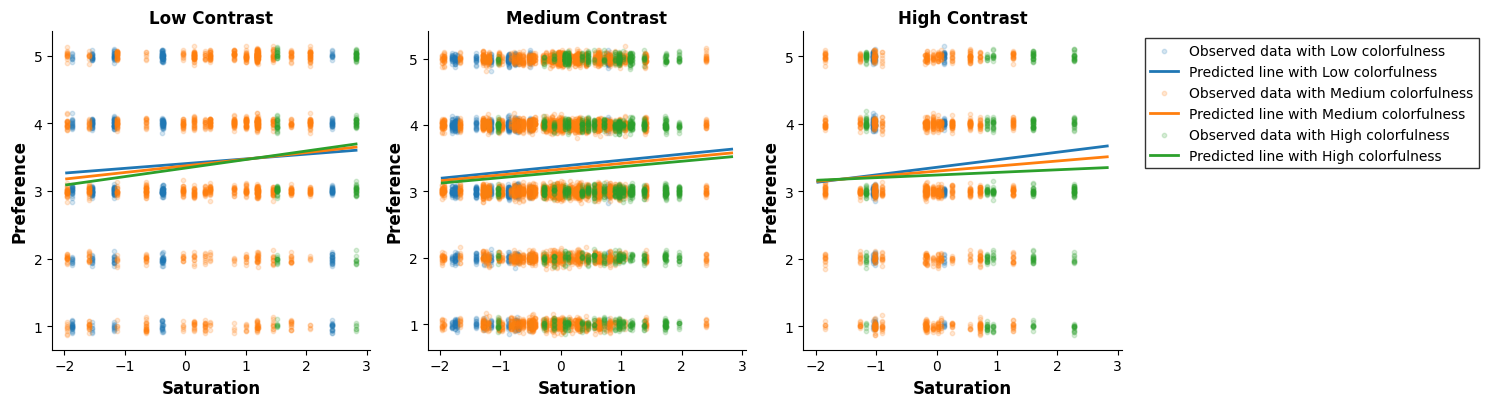

     saturation_mean  contrast_mean  colorfulness_mean contrast_level  \
0          -1.964235             -1                 -1            Low   
1          -1.915848             -1                 -1            Low   
2          -1.867461             -1                 -1            Low   
3          -1.819075             -1                 -1            Low   
4          -1.770688             -1                 -1            Low   
..               ...            ...                ...            ...   
895         2.632503              1                  1           High   
896         2.680890              1                  1           High   
897         2.729277              1                  1           High   
898         2.777663              1                  1           High   
899         2.826050              1                  1           High   

    colorfulness_level  predicted_preference  
0                  Low              3.266737  
1                  Low       

In [ ]:
# Final 
# -------------------------------------------
# Visualizing Model 2_3: Student-level data
# Three-way interaction between saturation, contrast, colorfulness
# -------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

df = pd.read_csv("../data/merged_data_v2.csv")

model2_3 = smf.mixedlm(
    "preference ~ saturation_mean * contrast_mean * colorfulness_mean",
    data=df,
    groups=df["student_id"]
# This model is fitted using maximum likelihood estimation (MLE), which is appropriate for comparing nested models. 
).fit(reml=False)


# ------------------------------------------------------------
# Categorize contrast and colorfulness into low, medium, and high groups
# ------------------------------------------------------------
# Since features are standardized:
# Low = below -1 SD
# Medium = between -1 SD and +1 SD
# High = above +1 SD

def categorize(x):
    if x < -1:
        return "Low"
    elif x > 1:
        return "High"
    else:
        return "Medium"


df["contrast_level"] = df["contrast_mean"].apply(categorize)
df["colorfulness_level"] = df["colorfulness_mean"].apply(categorize)


# ------------------------------------------------------------
# Adding jitter to observed preference ratings
# ------------------------------------------------------------
# Preference is an ordinal 1–5 rating, so many points overlap.
# Jitter slightly moves points vertically to make them visible.

# Sets random seed for reproducibility of jitter
np.random.seed(42)

df["preference_jitter"] = (
    df["preference"]
    + np.random.normal(loc=0, scale=0.05, size=len(df))
)


# ------------------------------------------------------------
# Create prediction data for all 9 combinations
# ------------------------------------------------------------
# Contrast levels: low, medium, high
# Colorfulness levels: low, medium, high
# Saturation varies continuously across its observed range.

# Creates 100 evenly spaced saturation values from the minimum to the maximum saturation value in data.
# Goal: to create smooth predicted lines across the saturation range for each contrast and colorfulness combination.
saturation_range = np.linspace(
    df["saturation_mean"].min(),
    df["saturation_mean"].max(),
    100
)

levels = {
    "Low": -1,
    "Medium": 0,
    "High": 1
}

prediction_rows = []

for contrast_label, contrast_value in levels.items():
    for colorfulness_label, colorfulness_value in levels.items():
        for saturation_value in saturation_range:
            prediction_rows.append({
                "saturation_mean": saturation_value,
                "contrast_mean": contrast_value,
                "colorfulness_mean": colorfulness_value,
                "contrast_level": contrast_label,
                "colorfulness_level": colorfulness_label
            })

pred_df = pd.DataFrame(prediction_rows)


# --------------------------------------
# Predict preference from Model 2_3
# --------------------------------------
# They are model-estimated preference values based on the fitted model.

pred_df["predicted_preference"] = model2_3.predict(pred_df)


# ------------------------------------------------------------
# Plot observed data and predicted lines
# ------------------------------------------------------------
# Three panels = Based on contrast levels
# Three lines per panel = Including colorfulness levels
# Dots = observed student-level preference ratings
# Lines = predicted preference from Model 2_3

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(15, 5)
)

for ax, (contrast_label, contrast_value) in zip(axes, levels.items()):

    # Observed data for this contrast group
    observed_contrast = df[df["contrast_level"] == contrast_label]

    # Predicted data for this contrast group
    predicted_contrast = pred_df[pred_df["contrast_level"] == contrast_label]

    for colorfulness_label in levels.keys():

        # Observed points for this colorfulness group
        observed_subset = observed_contrast[
            observed_contrast["colorfulness_level"] == colorfulness_label
        ]

        ax.scatter(
            observed_subset["saturation_mean"],
            observed_subset["preference_jitter"],
            alpha=0.18,
            s=10,
            label=f"Observed data with {colorfulness_label} colorfulness"
        )

        # Predicted line for this colorfulness group
        predicted_subset = predicted_contrast[
            predicted_contrast["colorfulness_level"] == colorfulness_label
        ]

        ax.plot(
            predicted_subset["saturation_mean"],
            predicted_subset["predicted_preference"],
            linewidth=2,
            label=f"Predicted line with {colorfulness_label} colorfulness"
        )

    ax.set_title(f"{contrast_label} Contrast", fontsize=12, weight="bold")
    ax.set_xlabel("Saturation", fontsize=12, weight="bold")
    ax.set_ylabel("Preference", fontsize=12, weight="bold")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_box_aspect(1)  # Set aspect ratio to 1:1 for square panels
    




axes[2].legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=True,
    edgecolor="black",
    fancybox=False
)

# plt.suptitle(
#    "...",
#    fontsize=14
#)

plt.tight_layout()
plt.show()

print(pred_df)